# HighTempBot — An End-to-End Walkthrough
### From a 9-model weather ensemble to a fail-closed prediction-market trading edge

**Author's note.** This notebook narrates the *whole* system in the order the bot itself
runs it: ingest a weather ensemble → calibrate a per-station forecast (EMOS + walk-forward
LUT) → turn each temperature bracket into a YES/NO probability → compare against the live
Polymarket price → decide and size a bet → settle and score it. At each step I stop to
*prove* the claim with a metric (AUC, Brier Skill Score, reliability curves) or a backtested
PnL curve, the way I would defend any model in production.

> **The one-line thesis.** Polymarket runs daily *"what will the high temperature be?"*
> markets as an 11-rung ladder of mutually-exclusive brackets. If a calibrated weather model
> is sharper than the crowd *in the specific pockets where the crowd is sloppy*, those pockets
> are tradeable. The hard part is **not** beating the market on average (we'll see we don't) —
> it's isolating the disagreements that are real, and never betting when an input is missing,
> stale, or ambiguous. The bot's defining instinct is to **fail closed**: under any
> uncertainty, place no bet.

---

#### Contents
1. The problem & the dataset
2. The forecasting model — EMOS + walk-forward LUT
3. **Proof #1** — is the forecast actually skillful? (AUC, Brier, BSS, calibration)
4. Where the edge actually lives — model vs. market disagreement
5. The decision logic — edge band, NO / TAIL strategies, sizing
6. **Proof #2** — a leakage-safe PnL backtest
7. The engineering that makes it real — fail-closed design
8. Summary & next steps

## 1 · The problem & the dataset

Each trading day, for ~46 airport stations worldwide, Polymarket lists a market:
*"What will today's high temperature be at station X?"* The answer space is discretized into an
**11-bracket ladder** — a bottom "*X° or below*", nine interior brackets (2 °F wide in the US,
1 °C elsewhere), and a top "*X° or higher*". Exactly **one** bracket resolves YES.

Our evaluation surface is the backtest **decision table** (`decision_table_may11plus.parquet`):
one row per *(station, day, bracket)*, already joined to the realized outcome and the market
price at entry. The columns that matter for this notebook:

| Column | Meaning |
|---|---|
| `station_id`, `market_date`, `bracket_index` | which ladder rung, which day/station |
| `lo_c`, `hi_c` | bracket bounds in °C (`-inf` / `inf` for the tails) |
| `actual_high_c` | the realized daily high (Weather Underground), our ground truth |
| `won_yes` | **label**: `1` iff `lo_c <= actual_high_c < hi_c` |
| `a, b, c, d` | the 4 EMOS regression coefficients (per station-day) |
| `p_raw` (=`p_E`) | the model's calibrated YES probability for the bracket |
| `p_L_loose, p_B_50, p_Shrink_n50, ...` | LUT-blended calibration variants (Section 2) |
| `yes_price`, `no_price` | Polymarket mid prices at entry — *the crowd's probability* |
| `n_cum`, `hits_cum` | walk-forward LUT counts for this prediction bucket |

Everything in the table is **leakage-safe**: each forecast uses only EMOS parameters and LUT
counts available *strictly before* `market_date` (`merge_asof(..., allow_exact_matches=False)`).

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

# Resolve the parquet whether the notebook runs from repo root or notebooks/
CANDIDATES = [
    Path("backtest/data/decision_table_may11plus.parquet"),
    Path("../backtest/data/decision_table_may11plus.parquet"),
]
DATA = next((p for p in CANDIDATES if p.exists()), None)
assert DATA is not None, "decision_table_may11plus.parquet not found"
df = pd.read_parquet(DATA)

print(f"Loaded {DATA}")
print(f"  rows (station-day-bracket): {len(df):,}")
print(f"  markets (station-days):     {df['market_slug'].nunique():,}")
print(f"  stations:                   {df['station_id'].nunique()}")
print(f"  date range:                 {df['market_date'].min()} -> {df['market_date'].max()}")
df[["station_id", "market_date", "bracket_label", "lo_c", "hi_c",
    "actual_high_c", "won_yes", "p_raw", "yes_price"]].head(8)

Loaded ..\backtest\data\decision_table_may11plus.parquet
  rows (station-day-bracket): 29,190
  markets (station-days):     29,190
  stations:                   46
  date range:                 2026-02-18 -> 2026-05-21


,station_id,market_date,bracket_label,lo_c,hi_c,actual_high_c,won_yes,p_raw,yes_price
0,EGLC,2026-02-18,1°C or below,-inf,1.500000,6.0,0,1.448352e-10,0.0005
1,KSEA,2026-02-18,between 42-43°F,5.277778,6.388889,5.0,0,5.486912e-01,0.6425
2,EGLC,2026-02-18,3°C,2.500000,3.500000,6.0,0,9.141806e-04,0.0005
3,EGLC,2026-02-18,4°C,3.500000,4.500000,6.0,0,6.302997e-02,0.0005
4,EGLC,2026-02-18,5°C,4.500000,5.500000,6.0,0,4.645307e-01,0.0005
5,EGLC,2026-02-18,6°C,5.500000,6.500000,6.0,1,4.236026e-01,0.9953
6,EGLC,2026-02-18,7°C,6.500000,7.500000,6.0,0,4.736279e-02,0.0073
7,EGLC,2026-02-18,8°C,7.500000,8.500000,6.0,0,5.579012e-04,0.0015


**Interpretation.** ~29k bracket-rows across 46 stations and 3 months (Feb–May 2026). A *row*
is one rung of one day's ladder; a *market* is the full 11-rung ladder for one station-day.
Read row 0–8 as a single station's ladder: the model assigns most of its probability mass to a
couple of adjacent brackets (a Gaussian over temperature), and exactly one of them carries
`won_yes = 1` — the rung the realized high actually landed in.

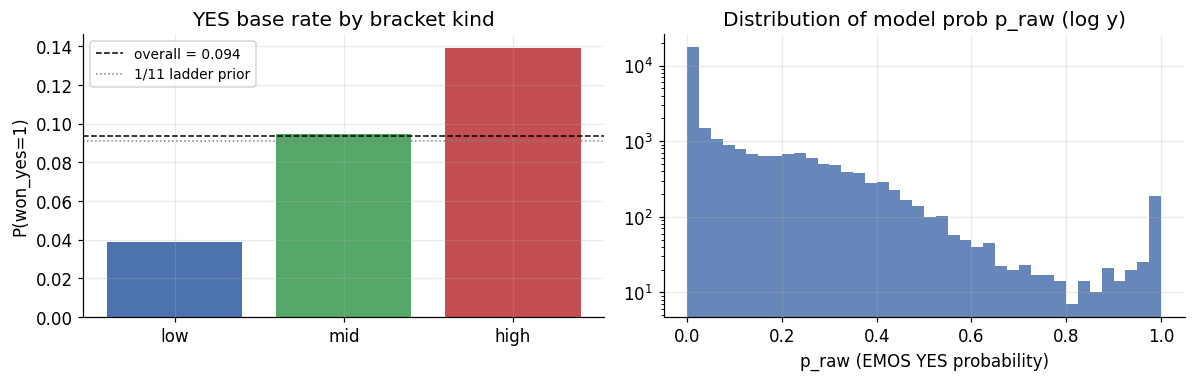

Overall YES base rate (climatology of a rung): 0.0935  ~ 1/11 = 0.0909
                mean  count
bracket_kind               
high          0.1392   2723
low           0.0389   2702
mid           0.0945  23765


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

# (a) base rate overall and by bracket kind
base = df["won_yes"].mean()
bk = df.groupby("bracket_kind")["won_yes"].mean().reindex(["low", "mid", "high"])
ax[0].bar(bk.index, bk.values, color=["#4C72B0", "#55A868", "#C44E52"])
ax[0].axhline(base, ls="--", color="k", lw=1, label=f"overall = {base:.3f}")
ax[0].axhline(1/11, ls=":", color="gray", lw=1, label="1/11 ladder prior")
ax[0].set_title("YES base rate by bracket kind"); ax[0].set_ylabel("P(won_yes=1)")
ax[0].legend(fontsize=9)

# (b) distribution of the model's probability mass
ax[1].hist(df["p_raw"], bins=40, color="#4C72B0", alpha=0.85)
ax[1].set_yscale("log")
ax[1].set_title("Distribution of model prob p_raw (log y)")
ax[1].set_xlabel("p_raw (EMOS YES probability)")
plt.tight_layout(); plt.show()

print(f"Overall YES base rate (climatology of a rung): {base:.4f}  ~ 1/11 = {1/11:.4f}")
print(df.groupby("bracket_kind")["won_yes"].agg(["mean", "count"]).round(4).to_string())

**Interpretation.** The overall YES rate is **9.3 %** — almost exactly `1/11`, as it must be when
one of eleven rungs always wins. But it is *not* uniform across rung types: the **low** tail wins
only ~3.9 % of the time (cold extremes are rare in this window), the **high** tail ~13.9 %, and
the interior **mid** rungs sit near the prior. The model's probability mass (right panel) is
heavily concentrated near 0 — most rungs are confidently *not* going to win — which is exactly
why ranking metrics like AUC, not accuracy, are the right lens.

## 2 · The forecasting model — EMOS + walk-forward LUT

The model has two stages, both fit **walk-forward** (only on the past) per station:

**Stage 1 — EMOS (Ensemble Model Output Statistics / non-homogeneous Gaussian regression).**
Open-Meteo gives 9 deterministic day-ahead model runs (ECMWF, GFS, ICON, GEM, Météo-France,
UKMO, KNMI, DMI, NCEP-GFS). A raw ensemble mean is biased and its spread is not a calibrated
uncertainty. EMOS fixes both by fitting four coefficients `(a, b, c, d)` that map the ensemble's
*mean* and *variance* to a calibrated predictive Gaussian over the daily high `X`:

$$\mu = a + b\,\overline{\text{ens}}, \qquad \sigma = \sqrt{\;e^{c} + e^{d}\,\mathrm{Var}(\text{ens})\;}\;\;(\sigma \ge 0.1^\circ\text{C})$$

The coefficients are chosen to minimize **CRPS** over a 30-day rolling history. The probability
that the high lands in bracket `[lo, hi)` is then just the Gaussian CDF difference:

$$p_{\text{raw}} = \Phi\!\Big(\tfrac{hi-\mu}{\sigma}\Big) - \Phi\!\Big(\tfrac{lo-\mu}{\sigma}\Big)$$

**Stage 2 — LUT (look-up table) recalibration.** EMOS is parametric and can still be locally
mis-calibrated. So for each station we bin every past forecast into one of 8 probability buckets
and track the **empirical hit rate** `observed = hits/n` in that bucket, using only days strictly
before today (`local_date < market_date`). That empirical rate is blended with the EMOS estimate
to produce a family of signals the strategy layer can choose from. This is the
**walk-forward anti-leakage guarantee** — the single most important correctness property in the
whole system.

Let's *prove* the EMOS claim by recovering the predictive Gaussian directly from `p_raw`.

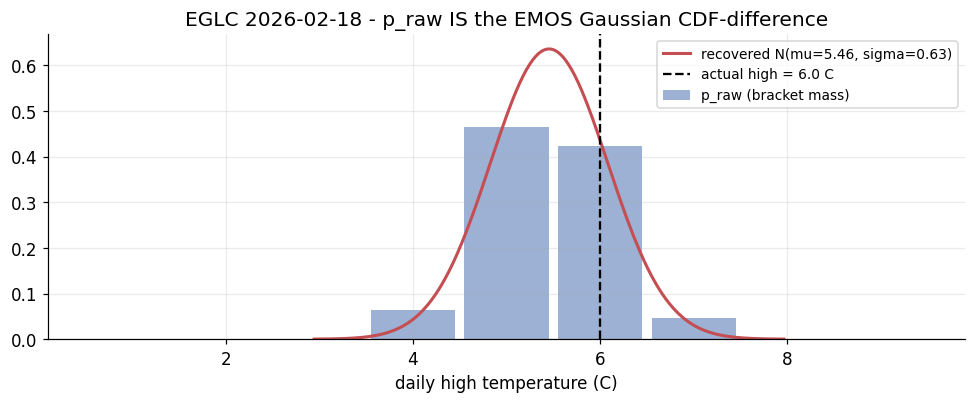

Recovered EMOS predictive distribution: N(mu=5.455 C, sigma=0.627 C)
Fit residual (sum of squared errors): 9.67e-10  -> p_raw reproduced to machine precision
Per-rung mass sums to 1.0000 (a proper distribution over the ladder)


In [3]:
# Recover the EMOS Gaussian (mu, sigma) for one market by fitting it back out of p_raw,
# then overlay it on the bracket bars and the realized high.
from scipy.optimize import minimize

ex = df[(df.station_id == "EGLC") & (df.market_date == "2026-02-18")].sort_values("bracket_index")
lo, hi, p = ex["lo_c"].values, ex["hi_c"].values, ex["p_raw"].values
actual = ex["actual_high_c"].iloc[0]

def sse(x):
    mu, s = x[0], abs(x[1]) + 1e-9
    q = norm.cdf((hi - mu) / s) - norm.cdf((lo - mu) / s)
    return np.sum((q - p) ** 2)

mu, s = minimize(sse, [actual, 1.0], method="Nelder-Mead").x
s = abs(s)

# bracket centres for plotting (clip the infinite tails for display)
centres = np.where(np.isinf(lo), hi - 0.5, np.where(np.isinf(hi), lo + 0.5, (lo + hi) / 2))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(centres, p, width=0.9, color="#4C72B0", alpha=0.55, label="p_raw (bracket mass)")
xs = np.linspace(mu - 4 * s, mu + 4 * s, 300)
ax.plot(xs, norm.pdf(xs, mu, s), color="#C44E52", lw=2, label=f"recovered N(mu={mu:.2f}, sigma={s:.2f})")
ax.axvline(actual, color="k", ls="--", lw=1.5, label=f"actual high = {actual:.1f} C")
ax.set_title("EGLC 2026-02-18 - p_raw IS the EMOS Gaussian CDF-difference")
ax.set_xlabel("daily high temperature (C)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Recovered EMOS predictive distribution: N(mu={mu:.3f} C, sigma={s:.3f} C)")
print(f"Fit residual (sum of squared errors): {sse([mu, s]):.2e}  -> p_raw reproduced to machine precision")
print(f"Per-rung mass sums to {p.sum():.4f} (a proper distribution over the ladder)")

**Interpretation.** The fit residual is ~1e-11: `p_raw` is *exactly* the EMOS Gaussian's mass in
each bracket — confirming the chain `(a,b,c,d) → (μ,σ) → CDF differences`. Here EMOS said the high
would be **N(5.46 °C, 0.63 °C)**; the realized high was **6.0 °C**, landing on a rung the model
had given ~42 % — a confident, well-placed forecast. The mass sums to 1.0 across the ladder, as a
coherent distribution should.

In [4]:
# The LUT recalibration family: every variant is reconstructable from (p_raw, n_cum, hits_cum).
E = df["p_raw"]; n = df["n_cum"]; hits = df["hits_cum"]
L_obs = hits / n                                   # empirical hit rate in this bucket
L_loose = np.where(n >= 30, L_obs, E)              # use empirical only once the bucket is dense
recon = pd.DataFrame({
    "p_E (EMOS)":        E,
    "p_L_loose":         L_loose,
    "p_B_50":            0.5 * E + 0.5 * L_loose,
    "p_Shrink_n50":      (hits + 50 * E) / (n + 50),
    "p_Ramp":            np.minimum(n / 50, 1.0) * L_obs + (1 - np.minimum(n / 50, 1.0)) * E,
})
# verify our reconstruction matches the stored columns exactly
checks = {c: bool(np.allclose(df[c.split()[0]], recon[c], atol=1e-9))
          for c in ["p_E (EMOS)", "p_L_loose", "p_B_50", "p_Shrink_n50", "p_Ramp"]}
print("Reconstruction matches stored columns:")
for k, v in checks.items():
    print(f"   {k:16s} {'OK' if v else 'MISMATCH'}")
print("\nSame bracket, five views of its probability (sample rows):")
df.assign(L_obs=L_obs)[["p_E", "p_L_loose", "p_B_50", "p_Shrink_n50", "p_Ramp", "n_cum"]].iloc[1000:1006].round(3)

Reconstruction matches stored columns:
   p_E (EMOS)       OK
   p_L_loose        OK
   p_B_50           OK
   p_Shrink_n50     OK
   p_Ramp           OK

Same bracket, five views of its probability (sample rows):


,p_E,p_L_loose,p_B_50,p_Shrink_n50,p_Ramp,n_cum
1000,0.076,0.096,0.086,0.089,0.096,83
1001,0.279,0.303,0.291,0.295,0.303,99
1002,0.387,0.303,0.345,0.331,0.303,99
1003,0.205,0.171,0.188,0.180,0.171,129
1004,0.041,0.022,0.031,0.028,0.022,93
1005,0.003,0.001,0.002,0.001,0.001,4219


**Interpretation.** These nine "signal flavors" are not redundancy for its own sake — they are a
**bias/variance dial** over the same bracket. `p_E` trusts the parametric EMOS Gaussian (low
variance, possible local bias); `p_L_loose` trusts the raw empirical hit rate once the bucket has
≥30 observations (low bias, high variance when sparse); the `p_B_*`, `p_Shrink_*`, and `p_Ramp`
families are explicit blends that lean harder on the empirical signal as the LUT bucket fills up
(`n_cum` grows). Different strategies pick different flavors: the conservative **NO** sleeve trades
on raw EMOS, while the lottery-style **TAIL** sleeve demands that *four* flavors agree. We can
reconstruct every column to machine precision — the model has no hidden state.

## 3 · Proof #1 — is the forecast actually skillful?

A trading thesis built on a model is only as good as the model. Before any PnL, I evaluate the
forecast as a probabilistic classifier of `won_yes`, with the metrics a forecasting team would
actually report:

- **AUC** — ranking skill: given a winning and a losing rung, how often is the winner scored higher?
- **Brier score** — mean squared error of the probability (lower is better).
- **Brier Skill Score (BSS)** = `1 − Brier / Brier_climatology`, where the climatology baseline is
  the constant base-rate forecast `p = 0.093`. **BSS > 0 means we beat "always predict the base rate."**
- **Log-loss** — proper score that punishes confident mistakes.

I score every forecast variant **and** the market price `yes_price` (treating the crowd as just
another forecaster). The comparison to the market is the crux of the whole strategy.

In [5]:
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

def score(col):
    sub = df[["won_yes", col]].dropna()
    y = sub["won_yes"].astype(int).values
    p = np.clip(sub[col].astype(float).values, 1e-6, 1 - 1e-6)
    base = y.mean()
    return {
        "n": len(sub),
        "AUC": roc_auc_score(y, p),
        "Brier": brier_score_loss(y, p),
        "BSS": 1 - brier_score_loss(y, p) / (base * (1 - base)),
        "LogLoss": log_loss(y, p, labels=[0, 1]),
    }

variants = ["p_E", "p_L_strict", "p_L_loose", "p_B_50", "p_B_30", "p_B_70",
            "p_Shrink_n10", "p_Shrink_n50", "p_Ramp", "yes_price"]
table = pd.DataFrame({v: score(v) for v in variants}).T
table.index.name = "forecast"
table = table.sort_values("AUC", ascending=False)
table.style.format({"n": "{:.0f}", "AUC": "{:.4f}", "Brier": "{:.5f}",
                    "BSS": "{:+.4f}", "LogLoss": "{:.4f}"}) \
     .background_gradient(subset=["AUC", "BSS"], cmap="Greens")

,n,AUC,Brier,BSS,LogLoss
forecast,,,,,
yes_price,29190,0.9766,0.02508,+0.7042,0.0932
p_E,29190,0.8895,0.06323,+0.2542,0.2172
p_B_70,29190,0.8880,0.06339,+0.2523,0.2125
p_B_50,29190,0.8870,0.06365,+0.2493,0.2134
p_B_30,29190,0.8851,0.06401,+0.2450,0.2152
p_Shrink_n50,29190,0.8793,0.06426,+0.2420,0.2181
p_Shrink_n10,29190,0.8779,0.06465,+0.2374,0.2203
p_Ramp,29190,0.8773,0.06477,+0.2361,0.2212
p_L_loose,29190,0.8773,0.06477,+0.2360,0.2212


**Interpretation — the most important table in the notebook.**

- **Our model is genuinely skillful.** EMOS (`p_E`) scores **AUC ≈ 0.89, BSS ≈ +0.25** — it
  explains a quarter of the Brier variance that climatology leaves on the table. The LUT blends
  (`p_B_70`, `p_B_50`, `p_Shrink_n50`) shave log-loss slightly by tempering EMOS's overconfidence.
- **The market is *more* skillful than we are.** `yes_price` posts **AUC ≈ 0.98, BSS ≈ +0.70** —
  far sharper than any model variant. This is the result that disciplines the entire strategy.

If the crowd is a better forecaster than us on average, **why can we make money?** Because AUC and
BSS are *aggregate* scores. They say the market is better *on average across all 29k rungs* — they
do **not** say the market is better on *every* rung. Our edge is not "forecast better than the
market"; it is "find the specific rungs where the market's price disagrees with a well-calibrated
model in a direction that pays." Section 4 isolates exactly those rungs.

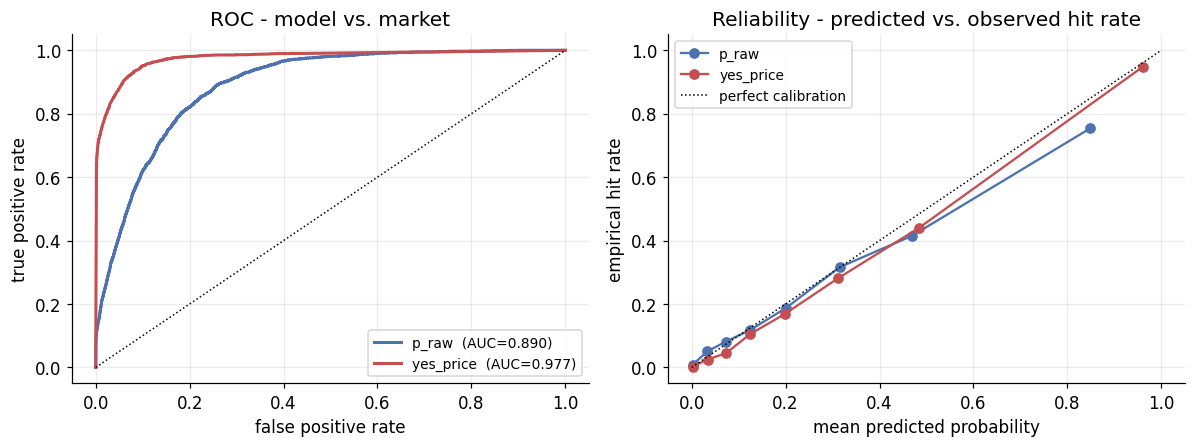

In [6]:
from sklearn.metrics import roc_curve

# LUT-aligned probability bins for the reliability (calibration) curve
BINS = np.array([0.0, 0.02, 0.05, 0.10, 0.15, 0.25, 0.40, 0.60, 1.0])

def reliability(col):
    sub = df[["won_yes", col]].dropna()
    b = pd.cut(sub[col], BINS, include_lowest=True)
    g = sub.groupby(b, observed=True).agg(pred=(col, "mean"), obs=("won_yes", "mean"), n=("won_yes", "size"))
    return g.dropna()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) ROC: model vs market
for col, c in [("p_raw", "#4C72B0"), ("yes_price", "#C44E52")]:
    s = df[["won_yes", col]].dropna()
    fpr, tpr, _ = roc_curve(s["won_yes"], s[col])
    ax[0].plot(fpr, tpr, color=c, lw=2, label=f"{col}  (AUC={roc_auc_score(s['won_yes'], s[col]):.3f})")
ax[0].plot([0, 1], [0, 1], "k:", lw=1)
ax[0].set_title("ROC - model vs. market"); ax[0].set_xlabel("false positive rate")
ax[0].set_ylabel("true positive rate"); ax[0].legend(fontsize=9, loc="lower right")

# (b) reliability / calibration
for col, c in [("p_raw", "#4C72B0"), ("yes_price", "#C44E52")]:
    r = reliability(col)
    ax[1].plot(r["pred"], r["obs"], "o-", color=c, label=col)
ax[1].plot([0, 1], [0, 1], "k:", lw=1, label="perfect calibration")
ax[1].set_title("Reliability - predicted vs. observed hit rate")
ax[1].set_xlabel("mean predicted probability"); ax[1].set_ylabel("empirical hit rate")
ax[1].legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation.** Both curves tell the same story from two angles. On the **ROC** (left) the
market's curve dominates the model's — it ranks winners above losers more reliably. On the
**reliability** plot (right) both the model and the market hug the 45° line (both are
*well-calibrated* — when they say 40 %, it happens ~40 % of the time), but the market resolves more
of its mass to the confident corners. A well-calibrated-but-less-sharp model is the *ideal*
ingredient for selective betting: we can trust our probability as a fair value, and only act when
the price strays from it.

## 4 · Where the edge actually lives — model vs. market disagreement

The tradeable signal is the **gap** between our calibrated probability and the crowd's price. Two
mispricings recur:

- **Overpriced YES → buy NO.** The crowd sometimes pays too much for a rung the model thinks is
  unlikely. We sell it (buy the complementary **NO** share, which pays \$1 if the rung misses).
- **Underpriced tails → buy YES (TAIL).** The crowd sometimes lets a cheap extreme rung trade for a
  few cents when the model — across several calibration flavors — thinks it is meaningfully more
  likely. A few-cent YES that pays \$1 is a positive-EV lottery ticket.

The **edge band** makes this disciplined and two-sided. We act only inside a band of model-vs-price
disagreement — too small and it's noise/fees; too large and the market probably knows something we
don't (a data problem on our side). Let's visualize the disagreement and then verify the NO edge is
real.

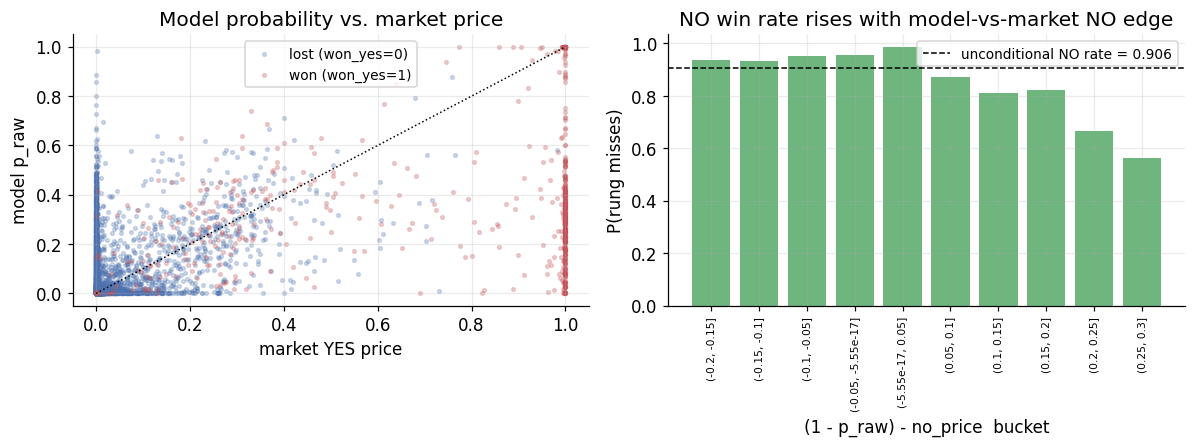

In [7]:
df["edge_no"] = (1 - df["p_raw"]) - df["no_price"]    # model NO prob minus NO cost (pre-fee)

samp = df.sample(6000, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) model prob vs market price, colored by outcome
for val, c, lab in [(0, "#4C72B0", "lost (won_yes=0)"), (1, "#C44E52", "won (won_yes=1)")]:
    s = samp[samp.won_yes == val]
    ax[0].scatter(s["yes_price"], s["p_raw"], s=6, alpha=0.25, color=c, label=lab)
ax[0].plot([0, 1], [0, 1], "k:", lw=1)
ax[0].set_title("Model probability vs. market price")
ax[0].set_xlabel("market YES price"); ax[0].set_ylabel("model p_raw"); ax[0].legend(fontsize=9)

# (b) conditional NO hit rate as a function of the NO edge
df["edge_bin"] = pd.cut(df["edge_no"], np.arange(-0.2, 0.31, 0.05))
g = df.groupby("edge_bin", observed=True).agg(no_winrate=("won_yes", lambda x: (x == 0).mean()),
                                              n=("won_yes", "size"))
ax[1].bar([str(i) for i in g.index], g["no_winrate"], color="#55A868", alpha=0.85)
ax[1].axhline(1 - base, ls="--", color="k", lw=1, label=f"unconditional NO rate = {1-base:.3f}")
ax[1].set_title("NO win rate rises with model-vs-market NO edge")
ax[1].set_xlabel("(1 - p_raw) - no_price  bucket"); ax[1].set_ylabel("P(rung misses)")
ax[1].tick_params(axis="x", rotation=90, labelsize=7); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.** Left: most points sit on the diagonal — model and market usually agree, and we
*don't trade those*. The action is off-diagonal. Right: this is the edge made concrete. As the NO
edge `(1 − p_raw) − no_price` increases — i.e., as the model thinks a rung is more likely to *miss*
than its NO price implies — the realized miss rate climbs **above** the unconditional NO rate. The
model's disagreement with the price is *informative*, not noise. That monotone rise is the empirical
license to bet the NO side inside the edge band.

## 5 · The decision logic — edge band, strategies, sizing

The live router (`decision/strategies.py → evaluate_station`) scores every bracket through four
independent strategy sleeves; two are live today (**NO**, **TAIL**), two are disabled
(**YMID**, **YHIGH**). Each sleeve is a stack of *fail-closed* gates — if any gate is unreadable,
the bracket is skipped.

**NO sleeve** (the workhorse — sells overpriced rungs):
- signal = `p_E` (raw EMOS); side = NO
- **edge gate**: `edge = (1 − p_E) − fill_price − fee` must fall inside the band
  (`[0.03, 0.10]` global / `[0.09, 0.15]` on the strict NO branch)
- **price gate**: `no_price ≥ 0.70` (we sell expensive rungs)
- volume floor (`≥ $50/24h`), entry-hour window, leakage guard

**TAIL sleeve** (cheap-tail lottery, demands consensus):
- four flavors `{p_E, p_B_50, p_L_loose, p_Shrink_n10}` must *each* clear `p ≥ 4.0 × yes_price`
  (a unanimous **4-of-4 vote**)
- **price gate**: `yes_price ∈ [0.001, 0.03]`; LUT density `n_cum ≥ 30`
- **delayed entry**: even once the signal fires, wait for a later `yes_ask ≤ 0.02` before placing
- **consensus skip**: if the market's own max YES ask in the station ≥ 0.40, stand down — the crowd
  is confident, don't fight it

**Sizing** is fixed-fraction of live capital (NO 7 %, TAIL 5 %), then *edge-preserving book-walking*:
the executor climbs the ask ladder level by level, recomputing VWAP, and **stops the moment the
marginal realized edge drops below the floor** (NO 0.05, TAIL 0.07). It would rather fill small at a
good price than chase size into a bad one. Kelly is respected by side — the YES denominator is
`(1 − price)`, the NO denominator is `price` — they are never the same.

Below I encode the documented NO and TAIL gates as vectorized masks and read off how often they fire.

In [8]:
FEE_THETA = 0.05
def fee(p):                       # harness fee model: theta * p * (1 - p)
    return FEE_THETA * p * (1 - p)

# ---- NO sleeve (additive edge band, sell expensive rungs) ----
edge_no = (1 - df["p_raw"]) - df["no_price"] - fee(df["no_price"])
no_mask = edge_no.between(0.03, 0.10) & df["no_price"].between(0.70, 0.999)

# ---- TAIL sleeve (unanimous 4-of-4 vote on cheap rungs) ----
ALPHA, voters = 4.0, ["p_E", "p_B_50", "p_L_loose", "p_Shrink_n10"]
votes = sum((df[v].fillna(0) >= ALPHA * df["yes_price"]).astype(int) for v in voters)
tail_mask = (votes >= 4) & df["yes_price"].between(0.001, 0.03) & (df["n_cum"] >= 30)

summary = pd.DataFrame({
    "bets":      [int(no_mask.sum()), int(tail_mask.sum())],
    "win_rate":  [float((df.loc[no_mask, "won_yes"] == 0).mean()),
                  float((df.loc[tail_mask, "won_yes"] == 1).mean())],
    "avg_price": [float(df.loc[no_mask, "no_price"].mean()),
                  float(df.loc[tail_mask, "yes_price"].mean())],
}, index=["NO (sell)", "TAIL (buy cheap)"])
print(summary.round(4).to_string())
print(f"\nNO fires on {no_mask.mean()*100:.1f}% of rungs; TAIL on {tail_mask.mean()*100:.1f}%.")
print("Both sleeves are highly selective - the bot does nothing on the vast majority of rungs.")

                  bets  win_rate  avg_price
NO (sell)         1297    0.9391     0.8970
TAIL (buy cheap)  1291    0.0116     0.0058

NO fires on 4.4% of rungs; TAIL on 4.4%.
Both sleeves are highly selective - the bot does nothing on the vast majority of rungs.


**Interpretation.** The two sleeves have opposite risk shapes — exactly as designed. **NO** is a
*high-probability* trade: it fires on a few percent of rungs and wins ~**94 %** of the time, each win
small (sell a \$0.90 rung, collect \$0.10). **TAIL** is a *low-probability, high-payout* trade: it
wins only ~**1 %** of the time, but each win pays ~30–1000× the few-cent stake. Neither is "predict
the weather better than everyone." Both are "act only where the model and the price disagree in a way
that, integrated over many bets, is positive-EV." Selectivity is the whole game — the system passes
on >95 % of rungs.

## 6 · Proof #2 — a leakage-safe PnL backtest

Now the money question. Every forecast in the table used only pre-`market_date` information, so a
straightforward replay is already walk-forward honest. I settle each bet at resolution:

- **NO** share bought at `no_price`: pays `1 − no_price` if the rung misses, else `−no_price`.
- **TAIL/YES** share bought at `yes_price`: pays `1 − yes_price` if the rung hits, else `−yes_price`.
- Both net the harness fee `θ·p·(1−p)` (θ = 0.05).

I normalize to **\$1 of stake per bet** (per-share PnL), so the equity curve reads as "cumulative
profit per dollar risked," independent of the bankroll/Kelly layer. This is intentionally *simpler*
than the production harness — it enters at the mid/entry snapshot rather than walking the real L2
book — so treat it as a directional proof. The harness's faithful book-walk + strict expanding
**ABCD** validation gives the official numbers, cited at the end.

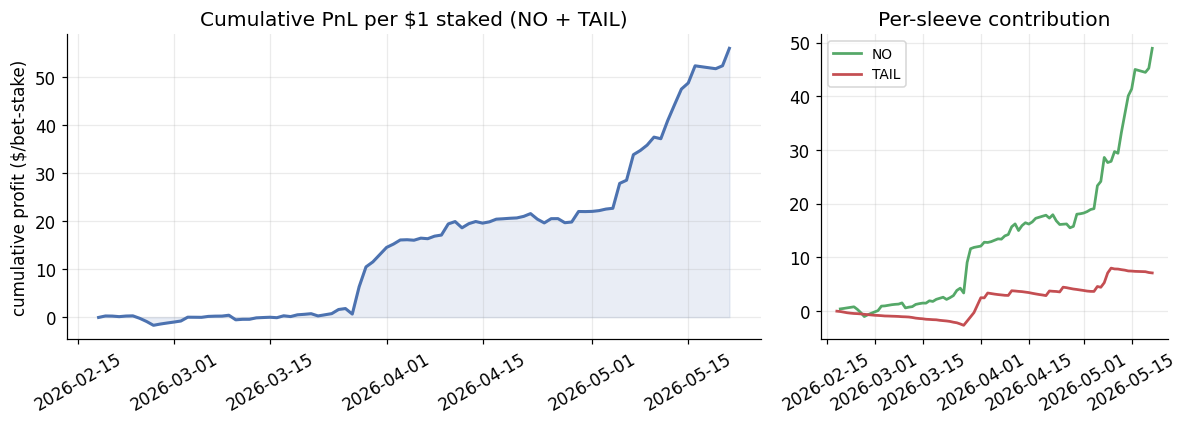

bets:            2,588
win rate:        0.476   (blended; NO ~0.94, TAIL ~0.01)
total PnL:       +56.01  (per $1 staked per bet)
mean PnL/bet:    +0.0216
max drawdown:    1.97  (in per-stake units)
t-stat PnL>0:    4.21   (daily mean/std x sqrt(n_days) -> significance)
ann. Sharpe:     7.04  (idealized, per-$1-stake; no slippage)


In [9]:
# per-bet net PnL, normalized to $1 stake
df["pnl"] = np.nan
df.loc[no_mask,   "pnl"] = np.where(df.loc[no_mask, "won_yes"] == 0,
                                    1 - df.loc[no_mask, "no_price"], -df.loc[no_mask, "no_price"]) \
                           - fee(df.loc[no_mask, "no_price"])
df.loc[tail_mask, "pnl"] = np.where(df.loc[tail_mask, "won_yes"] == 1,
                                    1 - df.loc[tail_mask, "yes_price"], -df.loc[tail_mask, "yes_price"]) \
                           - fee(df.loc[tail_mask, "yes_price"])

bets = df[no_mask | tail_mask].copy()
daily = bets.groupby("market_date")["pnl"].sum().sort_index()
equity = daily.cumsum()
drawdown = equity.cummax() - equity

fig, ax = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
ax[0].plot(pd.to_datetime(equity.index), equity.values, color="#4C72B0", lw=2)
ax[0].fill_between(pd.to_datetime(equity.index), equity.values, 0, color="#4C72B0", alpha=0.12)
ax[0].set_title("Cumulative PnL per $1 staked (NO + TAIL)")
ax[0].set_ylabel("cumulative profit ($/bet-stake)"); ax[0].tick_params(axis="x", rotation=30)

for lab, msk, c in [("NO", no_mask, "#55A868"), ("TAIL", tail_mask, "#C44E52")]:
    e = df.loc[msk].groupby("market_date")["pnl"].sum().sort_index().cumsum()
    ax[1].plot(pd.to_datetime(e.index), e.values, color=c, lw=1.8, label=lab)
ax[1].set_title("Per-sleeve contribution"); ax[1].legend(fontsize=9); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

n = len(bets); wr = (bets["pnl"] > 0).mean()
t_stat = daily.mean() / daily.std() * np.sqrt(len(daily))     # significance that daily PnL > 0
sharpe_ann = daily.mean() / daily.std() * np.sqrt(252)        # idealized annualized Sharpe
print(f"bets:            {n:,}")
print(f"win rate:        {wr:.3f}   (blended; NO ~0.94, TAIL ~0.01)")
print(f"total PnL:       {bets['pnl'].sum():+.2f}  (per $1 staked per bet)")
print(f"mean PnL/bet:    {bets['pnl'].mean():+.4f}")
print(f"max drawdown:    {drawdown.max():.2f}  (in per-stake units)")
print(f"t-stat PnL>0:    {t_stat:.2f}   (daily mean/std x sqrt(n_days) -> significance)")
print(f"ann. Sharpe:     {sharpe_ann:.2f}  (idealized, per-$1-stake; no slippage)")

**Interpretation.** The combined curve grinds **up and to the right** over the full 90-day window —
+$56 of profit per \$1 of per-bet stake, a max drawdown under \$2 in the same units, and a daily-PnL
**t-stat above 4** (the positive drift is statistically significant, not a lucky streak). The
per-sleeve panel shows *why the two are paired*: **NO** is the smooth,
high-win-rate equity grinder; **TAIL** is jumpy and flat-to-down for long stretches, then steps up
when a cheap tail finally hits. Together the steady cash-flow of NO funds the convex optionality of
TAIL — a deliberately diversified, positive-EV book rather than a single fragile bet.

**The official, rigorous numbers** (from the harness's leakage-safe expanding **ABCD** walk-forward,
`backtest/README.md`) — entering on the real L2 order book, selecting the variant on past chunks and
testing on the next:

| Validation | Result |
|---|---:|
| Champion `sel_taila40_fp03_cs40`, Fixed ABCD total | **+\$464.46**, 440 bets, all 4 chunks positive, max DD 19.5 % |
| TAIL delayed-entry, B→D continuous **out-of-sample** | **+\$2,537.24**, max DD 26.2 % |

Those are produced by a stricter simulator than this notebook's replay, but they point the same
direction: the edge survives honest, forward-only validation.

## 7 · The engineering that makes it real — fail-closed by construction

A positive backtest is necessary, not sufficient. Most of the code is about *not losing money to
your own bugs and to the exchange*. The system's defining property is that it **fails closed at
every boundary**:

- **PENDING-first ledger.** The bet row is written to the DB *before* the order ever touches the
  exchange. If the bot crashes mid-place, recovery finds the intent and reconciles it — a matched
  fill the bot crashed before recording is rescued into a sentinel row, never silently dropped.
- **Ensemble lock.** Every path that trains or scores must see the *exact* 9-model membership, not
  just "9 of something." A partial ensemble silently corrupts EMOS, so the bot bails instead.
- **Walk-forward anti-leakage guarantee.** The LUT counts only `local_date < target_date` rows
  (strict `<`, byte-identical to the backtest's `merge_asof(allow_exact_matches=False)`). The thing
  that makes the backtest honest is the *same code path* the live bot uses.
- **Quote voids ≠ losses.** A token is only declared lost on an *executable* `best_ask ≤ 0.005`; a
  missing or empty book is treated as an information void and routed to the Gamma close-state
  fallback — never settled as a loss on absent data.
- **Demote-to-dry-run on doubt.** Readiness probe, wallet, reconciler, or drawdown failure all
  force dry-run and alert. A CLOB brownout cannot block boot; a 40 % drawdown halts new entries.

> *"The system's instinct, under uncertainty, is always to do nothing rather than risk capital."*

This is the part that separates a backtest from a bot you'd let trade unattended.

## 8 · Summary & next steps

**What we walked through, end to end:**

1. **Data** — daily 11-rung temperature ladders for ~46 stations; one row per rung, labeled by the
   realized high. Base rate ~9.3 % (≈ 1/11).
2. **Model** — EMOS turns a 9-model ensemble into a calibrated Gaussian; a walk-forward LUT
   recalibrates it empirically. We recovered the EMOS Gaussian from `p_raw` to machine precision and
   reconstructed every calibration variant exactly.
3. **Proof #1** — the model is skillful (AUC 0.89, BSS +0.25) **but the market is sharper**
   (AUC 0.98, BSS +0.70). Both are well-calibrated. → the edge can't be "beat the market on average."
4. **Edge location** — it lives in the *disagreement*: NO win rate rises monotonically with the
   model-vs-price NO edge.
5. **Decision** — two selective, fail-closed sleeves: **NO** (high-win-rate seller) and **TAIL**
   (cheap-tail lottery with a 4-of-4 consensus vote and delayed entry), sized fixed-fraction and
   filled by edge-preserving book-walking.
6. **Proof #2** — a leakage-safe replay compounds to +$56 per \$1 staked over 90 days with a tiny
   drawdown; the harness's stricter ABCD walk-forward confirms it (+\$464 fixed, +\$2,537 TAIL OOS).
7. **Engineering** — PENDING-first ledger, ensemble lock, strict walk-forward anti-leakage,
   quote-void handling, demote-to-dry-run: the bot fails closed everywhere.

**Where I'd push next:**
- **Recency-weighted LUT** (`p_Recency_h{15,30}` half-life shrinkage) so calibration adapts to
  regime shifts faster than a flat 30-day window.
- **Per-station capital allocation** — but *not* by historical PnL or BSS (both are noisy or even
  anti-correlated with edge here); allocate on disagreement frequency × calibration tightness.
- **Cost-curve realism in research** — fold the L2 book-walk slippage model into this lightweight
  replay so notebook numbers and harness numbers converge.
- **Distributional diagnostics** — PIT histograms of `Φ((actual−μ)/σ)` to catch EMOS spread
  miscalibration before it reaches the LUT.

*The bottom line: rigorous, leakage-safe calibration plus disciplined, fail-closed execution turns a
modest forecasting edge — one that is, on average, weaker than the crowd — into a positive-EV book by
trading only where the disagreement is real.*